In [3]:
#Setup and Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)
from sklearn.impute import SimpleImputer

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("="*60)
print("FINANCIAL INCLUSION PREDICTION SYSTEM")
print("Global Findex Database 2025 Analysis")
print("="*60)

FINANCIAL INCLUSION PREDICTION SYSTEM
Global Findex Database 2025 Analysis


In [4]:
# Data Loading

DATA_PATH = 'global_findex_2025.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst 3 rows preview:")
df.head(3)

Dataset Shape: 144,090 rows × 199 columns

First 3 rows preview:


,year,economy,economycode,regionwb,pop_adult,wpid_random,wgt,female,age,educ,...,fin48e,fin48f,fin49a,fin49b,fin49c,fin49d,fin49e,fin49f,fin50,fin51
0,2024,Nicaragua,NIC,Latin America & Caribbean (excluding high income),4830854,111111345,0.927315,1,53,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024,Costa Rica,CRI,Latin America & Caribbean (excluding high income),4118576,111111579,1.383884,2,48,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024,Mali,MLI,Sub-Saharan Africa (excluding high income),12725942,111112511,1.323486,1,40,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


TARGET VARIABLE DISTRIBUTION (account ownership)
----------------------------------------
Has Account (Included): 106,312 (73.8%)
No Account (Excluded): 37,778 (26.2%)


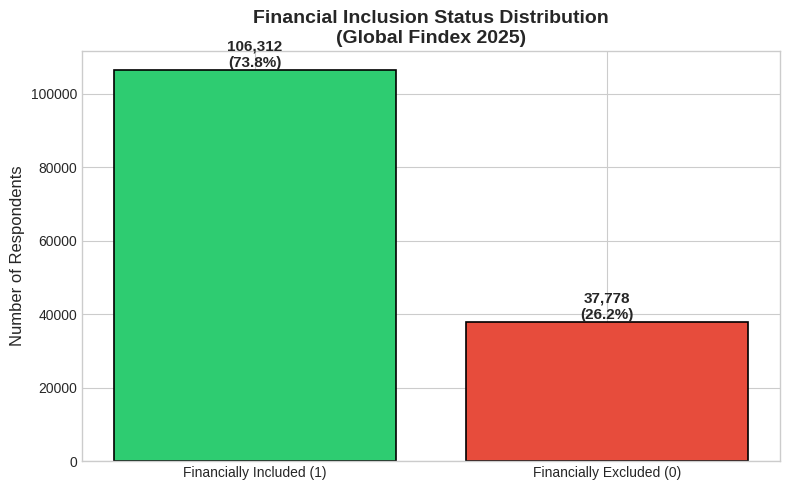

In [5]:
# Target Variable Analysis

# Target variable distribution
print("TARGET VARIABLE DISTRIBUTION (account ownership)")
print("-" * 40)
target_counts = df['account'].value_counts()
target_pct = df['account'].value_counts(normalize=True) * 100

for val, count, pct in zip(target_counts.index, target_counts.values, target_pct.values):
    label = "Has Account (Included)" if val == 1 else "No Account (Excluded)"
    print(f"{label}: {count:,} ({pct:.1f}%)")

# Visual
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
labels = ['Financially Included (1)', 'Financially Excluded (0)']
ax.bar(labels, target_counts.values, color=colors, edgecolor='black', linewidth=1.2)
ax.set_ylabel('Number of Respondents', fontsize=12)
ax.set_title('Financial Inclusion Status Distribution\n(Global Findex 2025)', fontsize=14, fontweight='bold')
for i, (v, p) in enumerate(zip(target_counts.values, target_pct.values)):
    ax.text(i, v + 1000, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Feature Selection for Modeling
# Select key features based on problem definition

# Define feature categories
FEATURE_DICT = {
    'Demographics': ['female', 'age', 'educ', 'inc_q', 'emp_in', 'urbanicity'],
    'Digital Connectivity': ['internet_use'],
    'Financial Behavior': ['saved', 'borrowed', 'receive_wages', 'receive_transfers',
                          'receive_pensions', 'anydigpayment', 'pay_utilities',
                          'domestic_remittances', 'merchantpay_dig']
}

# Create feature list
selected_features = []
for category, features in FEATURE_DICT.items():
    selected_features.extend(features)
    # Check which features exist in data
    existing = [f for f in features if f in df.columns]
    missing = [f for f in features if f not in df.columns]
    if missing:
        print(f"  {category}: Missing features - {missing}")

# Final feature list (only existing columns)
features = [f for f in selected_features if f in df.columns]
target = 'account'

print(f"\n✓ Final Feature Count: {len(features)}")
print(f"✓ Target Variable: {target}")
print("\nFeatures by Category:")
for cat, feats in FEATURE_DICT.items():
    existing = [f for f in feats if f in df.columns]
    print(f"  {cat}: {existing}")


✓ Final Feature Count: 16
✓ Target Variable: account

Features by Category:
  Demographics: ['female', 'age', 'educ', 'inc_q', 'emp_in', 'urbanicity']
  Digital Connectivity: ['internet_use']
  Financial Behavior: ['saved', 'borrowed', 'receive_wages', 'receive_transfers', 'receive_pensions', 'anydigpayment', 'pay_utilities', 'domestic_remittances', 'merchantpay_dig']


In [9]:
# Data Preprocessing
# Preprocessing pipeline

print("="*60)
print("DATA PREPROCESSING PIPELINE")
print("="*60)

# Create working copy
df_processed = df[features + [target]].copy()

# Step 1: Handle Missing Values
print("\n[1] MISSING VALUE ANALYSIS")
print("-" * 40)
missing_before = df_processed.isnull().sum()
missing_pct = (missing_before / len(df_processed) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': missing_before,
    'Missing %': missing_pct
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_summary.head(10))

# Impute missing values
# Numeric: median, Categorical: mode
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()

if len(numeric_cols) > 0:
    num_imputer = SimpleImputer(strategy='median')
    df_processed[numeric_cols] = num_imputer.fit_transform(df_processed[numeric_cols])
    
if len(categorical_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df_processed[categorical_cols] = cat_imputer.fit_transform(df_processed[categorical_cols])

print(f"\n✓ Missing values after imputation: {df_processed.isnull().sum().sum()}")

# Step 2: Encode Categorical Variables
print("\n[2] ENCODING CATEGORICAL VARIABLES")
print("-" * 40)
label_encoders = {}
for col in categorical_cols:
    if col != target:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        label_encoders[col] = le
        print(f"  Encoded: {col} ({len(le.classes_)} categories)")

# Step 3: Convert target to binary 
if df_processed[target].dtype == 'object':
    df_processed[target] = LabelEncoder().fit_transform(df_processed[target])

# Step 4: Final check
print("\n[3] PREPROCESSING SUMMARY")
print("-" * 40)
print(f"Final Dataset Shape: {df_processed.shape}")
print(f"Feature Types: {df_processed.dtypes.unique()}")
print(f"Target Balance: {df_processed[target].value_counts().to_dict()}")
print("\n✓ Preprocessing Complete!")

DATA PREPROCESSING PIPELINE

[1] MISSING VALUE ANALYSIS
----------------------------------------
                      Missing Count  Missing %
receive_wages                 52189      36.22
receive_transfers             52189      36.22
receive_pensions              52189      36.22
pay_utilities                 52189      36.22
saved                         41136      28.55
borrowed                      41136      28.55
anydigpayment                 41136      28.55
merchantpay_dig               41136      28.55
domestic_remittances          11817       8.20
emp_in                         4020       2.79

✓ Missing values after imputation: 0

[2] ENCODING CATEGORICAL VARIABLES
----------------------------------------

[3] PREPROCESSING SUMMARY
----------------------------------------
Final Dataset Shape: (144090, 17)
Feature Types: [dtype('float64')]
Target Balance: {1.0: 106312, 0.0: 37778}

✓ Preprocessing Complete!


EXPLORATORY DATA ANALYSIS


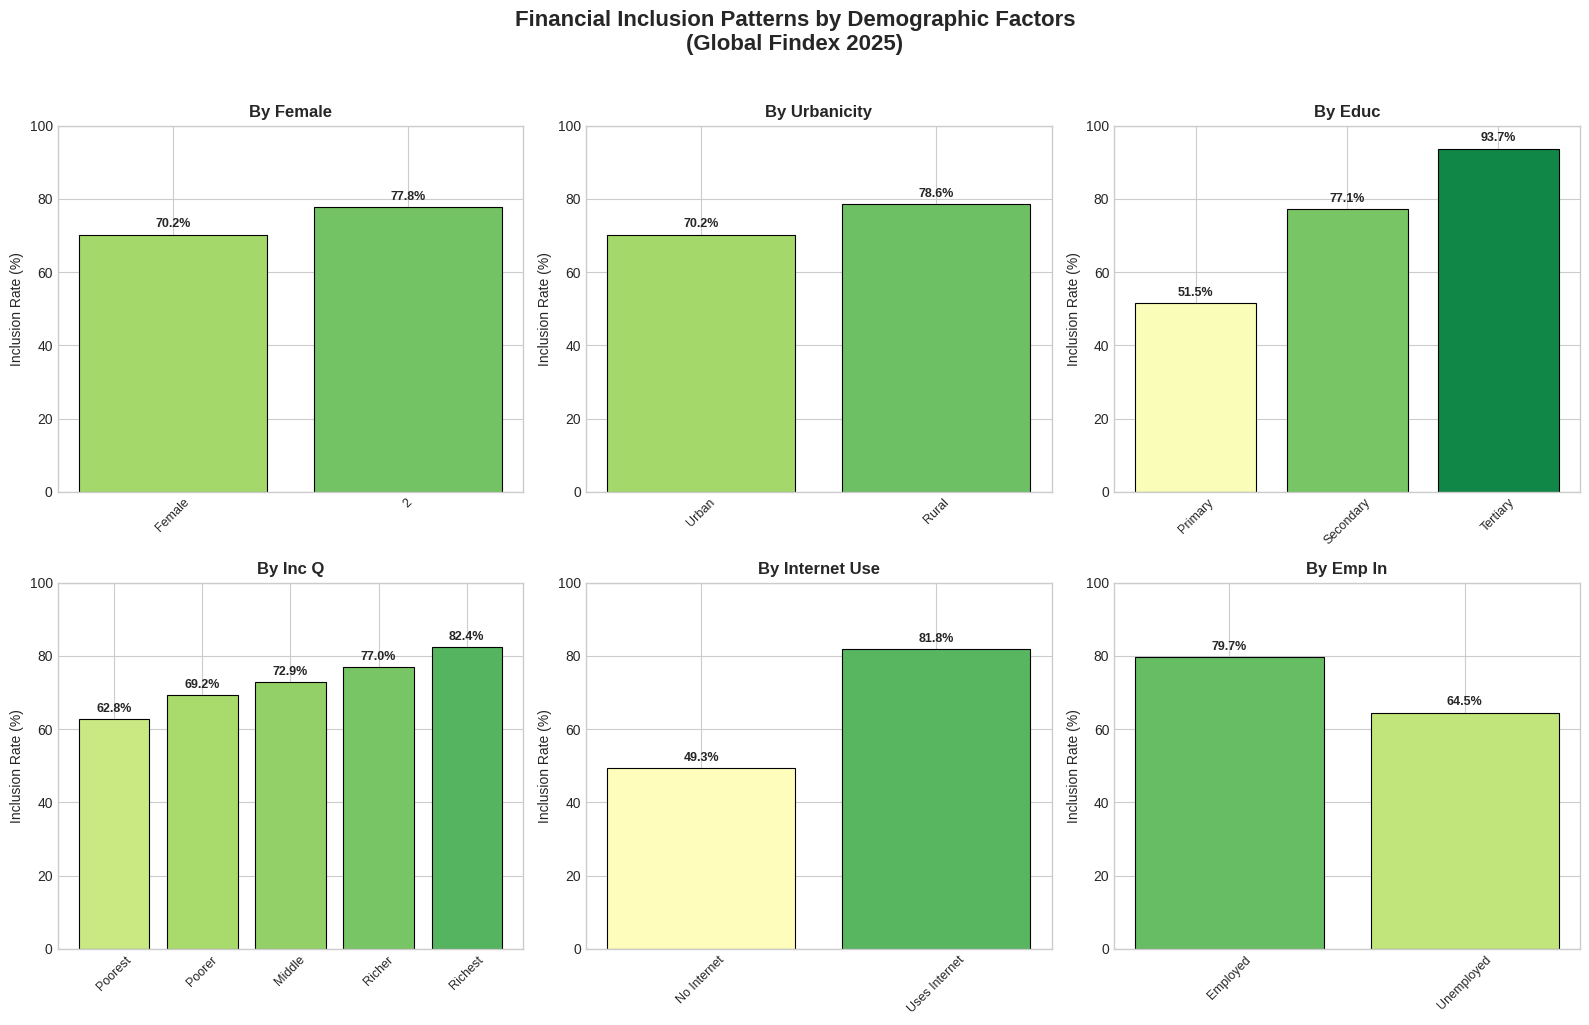


Key Insights from EDA:
----------------------------------------
• Gender Gap: Male 0.0% vs Female 70.2%
• Urban-Rural Gap: Urban 70.2% vs Rural 78.6%
• Digital Divide: Internet users 81.8% vs Non-users 49.3%


In [10]:
# Exploratory Data Analysis (EDA)

print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Prepare data for EDA
df_eda = df_processed.copy()

# Map labels for better visualization
label_maps = {
    'female': {0: 'Male', 1: 'Female'},
    'urbanicity': {1: 'Urban', 2: 'Rural'},
    'educ': {1: 'Primary', 2: 'Secondary', 3: 'Tertiary', 4: 'Other'},
    'inc_q': {1: 'Poorest', 2: 'Poorer', 3: 'Middle', 4: 'Richer', 5: 'Richest'}
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Financial Inclusion Patterns by Demographic Factors\n(Global Findex 2025)', 
             fontsize=16, fontweight='bold', y=1.02)

eda_vars = ['female', 'urbanicity', 'educ', 'inc_q']
if 'internet_use' in df_eda.columns:
    label_maps['internet_use'] = {0: 'No Internet', 1: 'Uses Internet'}
    eda_vars.append('internet_use')
if 'emp_in' in df_eda.columns:
    label_maps['emp_in'] = {1: 'Employed', 2: 'Unemployed'}
    eda_vars.append('emp_in')

colors_included = '#2ecc71'
colors_excluded = '#e74c3c'

for idx, var in enumerate(eda_vars[:6]):
    ax = axes[idx // 3, idx % 3]
    
    # Calculate inclusion rate by category
    if var in label_maps:
        grouped = df_eda.groupby(var)[target].agg(['sum', 'count'])
        grouped['inclusion_rate'] = (grouped['sum'] / grouped['count'] * 100).round(1)
        grouped.index = grouped.index.map(lambda x: label_maps.get(var, {}).get(int(x), str(int(x))))
    else:
        grouped = df_eda.groupby(var)[target].agg(['sum', 'count'])
        grouped['inclusion_rate'] = (grouped['sum'] / grouped['count'] * 100).round(1)
    
    bars = ax.bar(grouped.index.astype(str), grouped['inclusion_rate'], 
                  color=plt.cm.RdYlGn(grouped['inclusion_rate']/100), 
                  edgecolor='black', linewidth=0.8)
    
    ax.set_title(f'By {var.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Inclusion Rate (%)', fontsize=10)
    ax.set_ylim(0, 100)
    
    # Add value labels
    for bar, val in zip(bars, grouped['inclusion_rate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                f'{val}%', ha='center', fontsize=9, fontweight='bold')
    
    ax.tick_params(axis='x', rotation=45, labelsize=9)

plt.tight_layout()
plt.savefig('02_eda_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insights from EDA:")
print("-" * 40)
if 'female' in df_eda.columns:
    gender_rate = df_eda.groupby('female')[target].mean() * 100
    print(f"• Gender Gap: Male {gender_rate.get(0, 0):.1f}% vs Female {gender_rate.get(1, 0):.1f}%")
if 'urbanicity' in df_eda.columns:
    urban_rate = df_eda.groupby('urbanicity')[target].mean() * 100
    print(f"• Urban-Rural Gap: Urban {urban_rate.get(1, 0):.1f}% vs Rural {urban_rate.get(2, 0):.1f}%")
if 'internet_use' in df_eda.columns:
    internet_rate = df_eda.groupby('internet_use')[target].mean() * 100
    print(f"• Digital Divide: Internet users {internet_rate.get(1, 0):.1f}% vs Non-users {internet_rate.get(0, 0):.1f}%")

FEATURE CORRELATION WITH FINANCIAL INCLUSION
------------------------------------------------------------


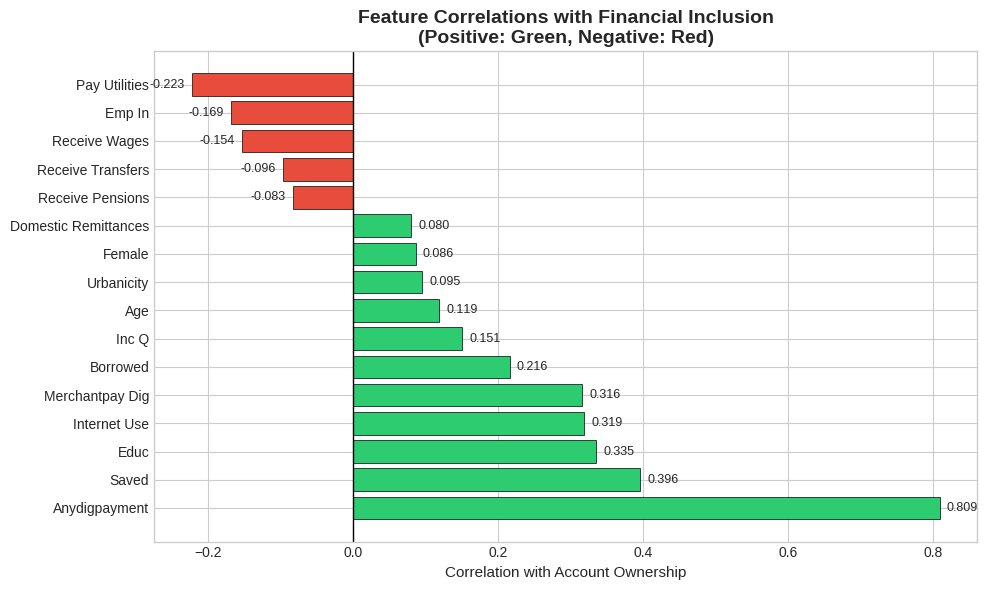


Top 5 Positive Correlations:
  anydigpayment: 0.8089
  saved: 0.3958
  educ: 0.3350
  internet_use: 0.3190
  merchantpay_dig: 0.3156

Top 3 Negative Correlations:
  receive_wages: -0.1536
  emp_in: -0.1686
  pay_utilities: -0.2229


In [11]:
# Correlation Analysis

print("FEATURE CORRELATION WITH FINANCIAL INCLUSION")
print("-" * 60)

# Calculate correlations with target
correlations = df_eda[features + [target]].corr()[target].drop(target).sort_values(ascending=False)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in correlations.values]
bars = ax.barh(range(len(correlations)), correlations.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(correlations)))
ax.set_yticklabels([f.replace('_', ' ').title() for f in correlations.index])
ax.set_xlabel('Correlation with Account Ownership', fontsize=11)
ax.set_title('Feature Correlations with Financial Inclusion\n(Positive: Green, Negative: Red)', 
             fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=1)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, correlations.values)):
    ax.text(val + (0.01 if val >= 0 else -0.01), i, f'{val:.3f}', 
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('03_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 Positive Correlations:")
for feat, corr in correlations.head(5).items():
    print(f"  {feat}: {corr:.4f}")
print("\nTop 3 Negative Correlations:")
for feat, corr in correlations.tail(3).items():
    print(f"  {feat}: {corr:.4f}")

In [12]:
# Train-Test Split and Feature Scaling

print("="*60)
print("MODEL PREPARATION")
print("="*60)

# Separate features and target
X = df_processed[features].copy()
y = df_processed[target].copy()

# Train-test split (80-20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nDataset Split:")
print(f"  Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Features: {X_train.shape[1]}")
print(f"\nClass Distribution in Training:")
print(f"  Included (1): {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"  Excluded (0): {(1-y_train).sum():,} ({(1-y_train).mean()*100:.1f}%)")

# Feature scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Feature scaling applied (StandardScaler)")
print("✓ Data ready for modeling")

MODEL PREPARATION

Dataset Split:
  Training set: 115,272 samples (80.0%)
  Test set: 28,818 samples (20.0%)
  Features: 16

Class Distribution in Training:
  Included (1): 85,050.0 (73.8%)
  Excluded (0): 30,222.0 (26.2%)

✓ Feature scaling applied (StandardScaler)
✓ Data ready for modeling


BASELINE MODEL: LOGISTIC REGRESSION

Performance Metrics:
----------------------------------------
  Accuracy: 0.9235
  Precision: 0.9785
  Recall: 0.9165
  F1-Score: 0.9465
  ROC-AUC: 0.9546

Classification Report:
              precision    recall  f1-score   support

    Excluded       0.80      0.94      0.87      7556
    Included       0.98      0.92      0.95     21262

    accuracy                           0.92     28818
   macro avg       0.89      0.93      0.91     28818
weighted avg       0.93      0.92      0.93     28818



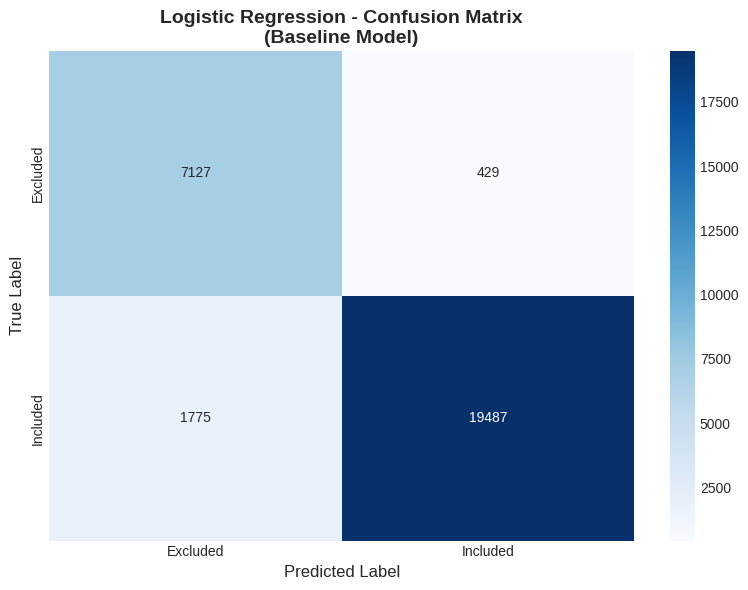

In [13]:
# Baseline Model - Logistic Regression

print("="*60)
print("BASELINE MODEL: LOGISTIC REGRESSION")
print("="*60)

# Initialize and train
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
lr_metrics = {
    'Accuracy': accuracy_score(y_test, lr_preds),
    'Precision': precision_score(y_test, lr_preds),
    'Recall': recall_score(y_test, lr_preds),
    'F1-Score': f1_score(y_test, lr_preds),
    'ROC-AUC': roc_auc_score(y_test, lr_probs)
}

print("\nPerformance Metrics:")
print("-" * 40)
for metric, value in lr_metrics.items():
    print(f"  {metric}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=['Excluded', 'Included']))

# Confusion Matrix Visualization
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Excluded', 'Included'],
            yticklabels=['Excluded', 'Included'])
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Logistic Regression - Confusion Matrix\n(Baseline Model)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

IMPROVED MODEL 1: RANDOM FOREST

Performance Metrics:
----------------------------------------
  Accuracy: 0.9230 (-0.0006 vs baseline)
  Precision: 0.9804 (+0.0020 vs baseline)
  Recall: 0.9138 (-0.0027 vs baseline)
  F1-Score: 0.9460 (-0.0005 vs baseline)
  ROC-AUC: 0.9672 (+0.0126 vs baseline)


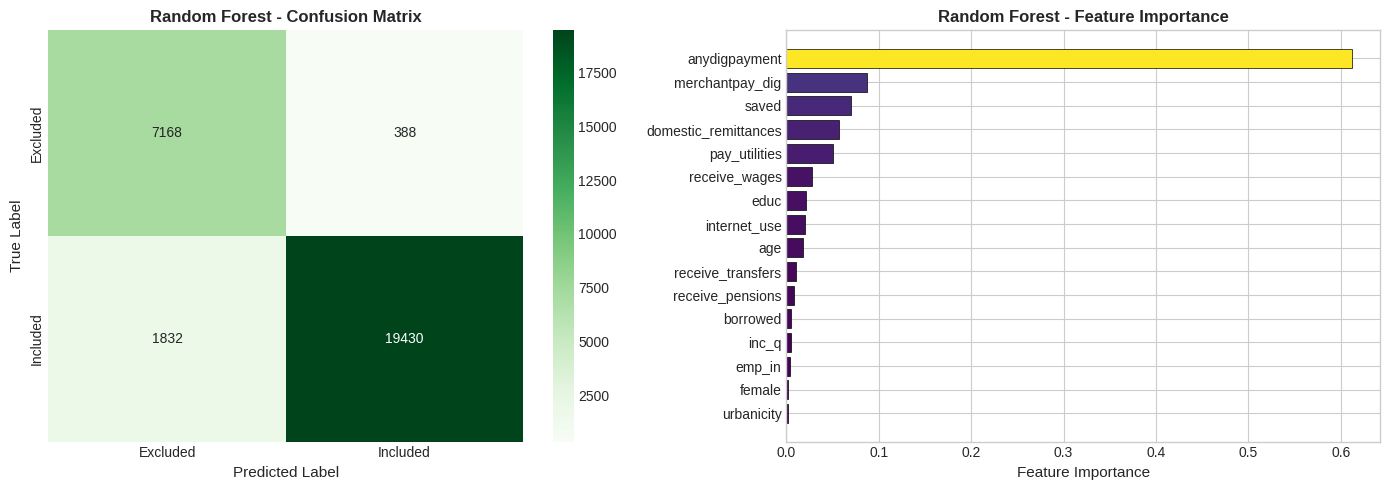

In [14]:
# Improved Model 1 - Random Forest

print("="*60)
print("IMPROVED MODEL 1: RANDOM FOREST")
print("="*60)

# Initialize and train
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)  # No scaling needed for tree-based

# Predictions
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
rf_metrics = {
    'Accuracy': accuracy_score(y_test, rf_preds),
    'Precision': precision_score(y_test, rf_preds),
    'Recall': recall_score(y_test, rf_preds),
    'F1-Score': f1_score(y_test, rf_preds),
    'ROC-AUC': roc_auc_score(y_test, rf_probs)
}

print("\nPerformance Metrics:")
print("-" * 40)
for metric, value in rf_metrics.items():
    lr_val = lr_metrics[metric]
    diff = value - lr_val
    sign = '+' if diff > 0 else ''
    print(f"  {metric}: {value:.4f} ({sign}{diff:.4f} vs baseline)")

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest CM
cm_rf = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Excluded', 'Included'],
            yticklabels=['Excluded', 'Included'])
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=12, fontweight='bold')

# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
axes[1].barh(importances.index, importances.values, color=plt.cm.viridis(importances.values/importances.max()),
             edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Feature Importance', fontsize=11)
axes[1].set_title('Random Forest - Feature Importance', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('05_random_forest_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Improved Model 2 - XGBoost

print("="*60)
print("IMPROVED MODEL 2: XGBOOST")
print("="*60)

# Calculate scale_pos_weight for imbalanced data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Initialize and train
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# Predictions
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
xgb_metrics = {
    'Accuracy': accuracy_score(y_test, xgb_preds),
    'Precision': precision_score(y_test, xgb_preds),
    'Recall': recall_score(y_test, xgb_preds),
    'F1-Score': f1_score(y_test, xgb_preds),
    'ROC-AUC': roc_auc_score(y_test, xgb_probs)
}

print("\nPerformance Metrics:")
print("-" * 40)
for metric, value in xgb_metrics.items():
    lr_val = lr_metrics[metric]
    diff = value - lr_val
    sign = '+' if diff > 0 else ''
    print(f"  {metric}: {value:.4f} ({sign}{diff:.4f} vs baseline)")

print("\nClassification Report:")
print(classification_report(y_test, xgb_preds, target_names=['Excluded', 'Included']))

IMPROVED MODEL 2: XGBOOST

Performance Metrics:
----------------------------------------
  Accuracy: 0.9216 (-0.0019 vs baseline)
  Precision: 0.9820 (+0.0036 vs baseline)
  Recall: 0.9105 (-0.0061 vs baseline)
  F1-Score: 0.9449 (-0.0016 vs baseline)
  ROC-AUC: 0.9667 (+0.0121 vs baseline)

Classification Report:
              precision    recall  f1-score   support

    Excluded       0.79      0.95      0.86      7556
    Included       0.98      0.91      0.94     21262

    accuracy                           0.92     28818
   macro avg       0.89      0.93      0.90     28818
weighted avg       0.93      0.92      0.92     28818



MODEL COMPARISON SUMMARY

                                Accuracy  Precision    Recall  F1-Score   ROC-AUC
Logistic Regression (Baseline)  0.923520   0.978460  0.916518  0.946476  0.954610
Random Forest                   0.922965   0.980422  0.913837  0.945959  0.967215
XGBoost                         0.921646   0.982041  0.910451  0.944892  0.966662

------------------------------------------------------------

Best Model by Metric:
  Accuracy: Logistic Regression (Baseline) (0.9235)
  Precision: XGBoost (0.9820)
  Recall: Logistic Regression (Baseline) (0.9165)
  F1-Score: Logistic Regression (Baseline) (0.9465)
  ROC-AUC: Random Forest (0.9672)


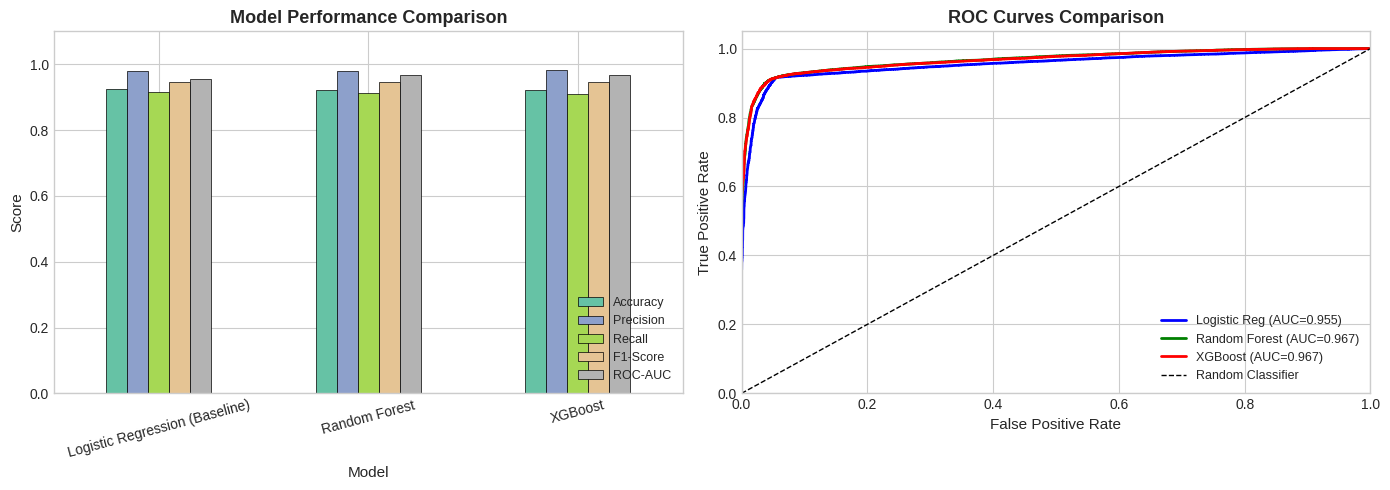


✓ Model comparison complete!


In [16]:
# Model Comparison

print("="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Logistic Regression (Baseline)': lr_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics
}).T

print("\n" + comparison_df.to_string())
print("\n" + "-"*60)

# Find best model for each metric
print("\nBest Model by Metric:")
for metric in comparison_df.columns:
    best = comparison_df[metric].idxmax()
    best_val = comparison_df[metric].max()
    print(f"  {metric}: {best} ({best_val:.4f})")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics comparison
comparison_df.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_xlabel('Model', fontsize=11)
axes[0].set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].tick_params(axis='x', rotation=15)
axes[0].set_ylim(0, 1.1)

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

axes[1].plot(fpr_lr, tpr_lr, 'b-', linewidth=2, label=f'Logistic Reg (AUC={lr_metrics["ROC-AUC"]:.3f})')
axes[1].plot(fpr_rf, tpr_rf, 'g-', linewidth=2, label=f'Random Forest (AUC={rf_metrics["ROC-AUC"]:.3f})')
axes[1].plot(fpr_xgb, tpr_xgb, 'r-', linewidth=2, label=f'XGBoost (AUC={xgb_metrics["ROC-AUC"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curves Comparison', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Model comparison complete!")

MODEL INTERPRETATION: SHAP ANALYSIS

SHAP values calculated for 5,000 samples


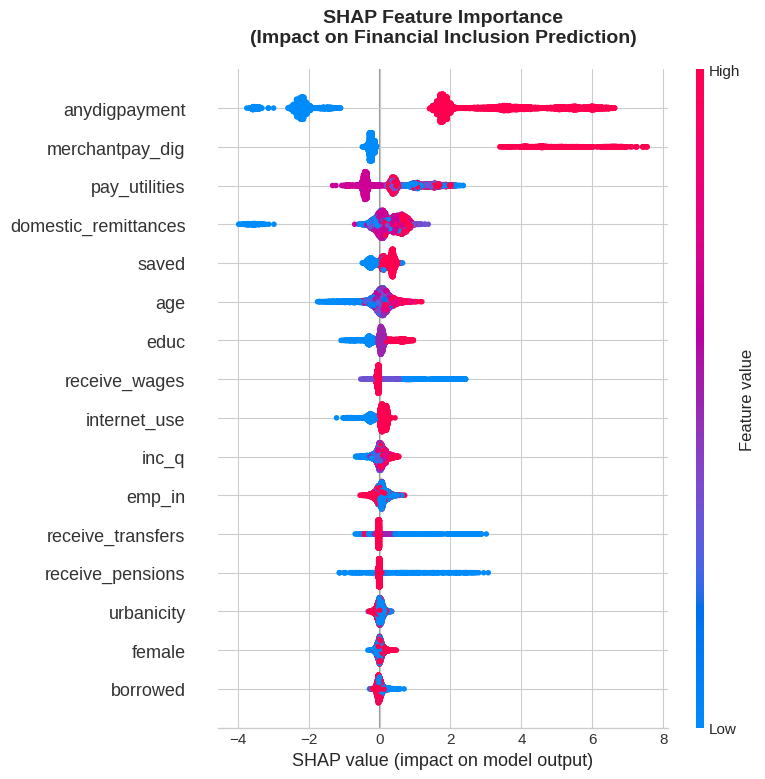


Top 10 Most Influential Features (by SHAP):
--------------------------------------------------
  anydigpayment: 2.8538
  merchantpay_dig: 1.2866
  pay_utilities: 0.7140
  domestic_remittances: 0.4341
  saved: 0.2513
  age: 0.2489
  educ: 0.2113
  receive_wages: 0.2079
  internet_use: 0.1604
  inc_q: 0.1225


In [19]:
# Model Interpretation with SHAP

print("="*60)
print("MODEL INTERPRETATION: SHAP ANALYSIS")
print("="*60)

import shap

# Initialize SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values (sample for speed if needed)
sample_size = min(5000, len(X_test))
X_sample = X_test.iloc[:sample_size]
shap_values = explainer.shap_values(X_sample)

print(f"\nSHAP values calculated for {sample_size:,} samples")

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=features, show=False)
plt.title('SHAP Feature Importance\n(Impact on Financial Inclusion Prediction)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('07_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Top features by mean absolute SHAP value
shap_importance = pd.DataFrame({
    'Feature': features,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)

print("\nTop 10 Most Influential Features (by SHAP):")
print("-" * 50)
for i, row in shap_importance.head(10).iterrows():
    print(f"  {row['Feature']}: {row['Mean |SHAP|']:.4f}")

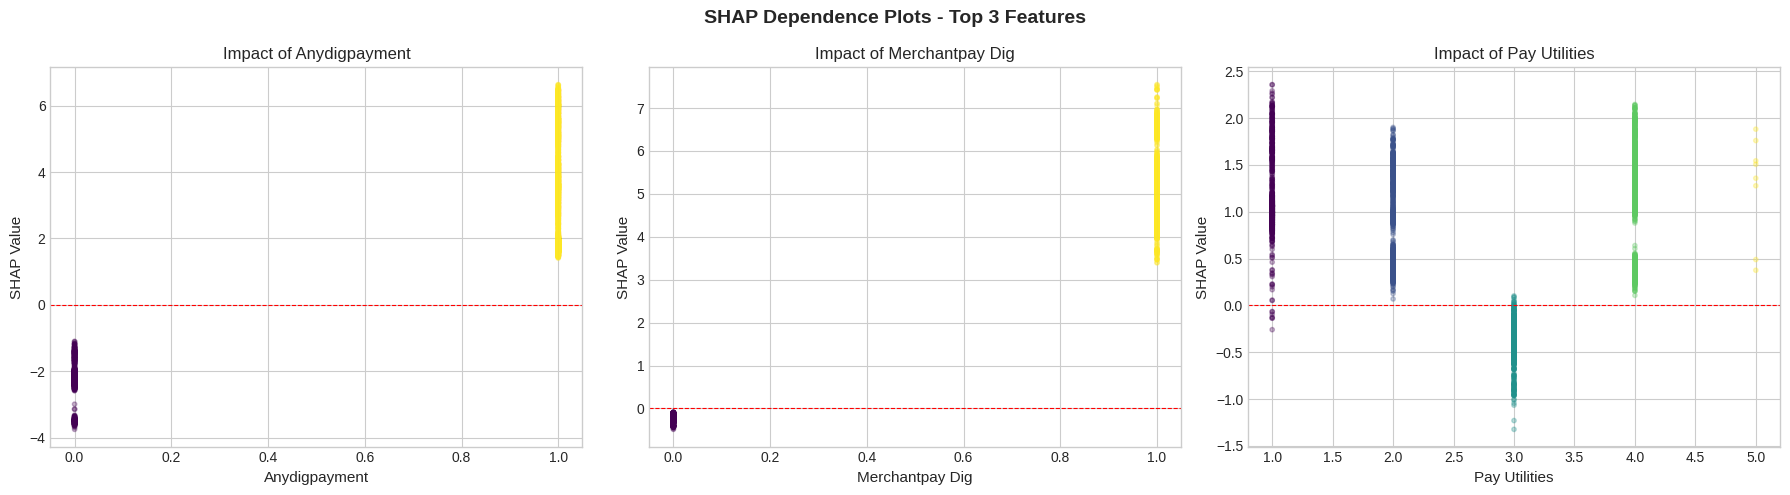


Key Interpretation Insights:
--------------------------------------------------
• Positive SHAP values → Increase probability of financial inclusion
• Negative SHAP values → Decrease probability of financial inclusion
• Feature distributions show which values drive inclusion/exclusion


In [20]:
# SHAP Detailed Analysis for Top Features

# Detailed SHAP dependence plots for top 3 features
top_3_features = shap_importance['Feature'].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SHAP Dependence Plots - Top 3 Features', fontsize=14, fontweight='bold')

for idx, feat in enumerate(top_3_features):
    feat_idx = features.index(feat)
    axes[idx].scatter(X_sample[feat].values, shap_values[:, feat_idx], 
                     alpha=0.3, c=X_sample[feat].values, cmap='viridis', s=10)
    axes[idx].set_xlabel(feat.replace('_', ' ').title(), fontsize=11)
    axes[idx].set_ylabel('SHAP Value', fontsize=11)
    axes[idx].set_title(f'Impact of {feat.replace("_", " ").title()}', fontsize=12)
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('08_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Interpretation Insights:")
print("-" * 50)
print("• Positive SHAP values → Increase probability of financial inclusion")
print("• Negative SHAP values → Decrease probability of financial inclusion")
print("• Feature distributions show which values drive inclusion/exclusion")

INDIVIDUAL PREDICTION EXPLANATION

--- Individual 1 ---
Actual: Included
Predicted: Excluded (Probability: 5.54%)
Top 5 Contributing Factors:
  ↓ anydigpayment: value=0.0, SHAP=-2.2672
  ↓ age: value=20.0, SHAP=-0.4805
  ↑ pay_utilities: value=4.0, SHAP=0.3658
  ↓ merchantpay_dig: value=0.0, SHAP=-0.2736
  ↓ saved: value=0.0, SHAP=-0.1917

--- Individual 2 ---
Actual: Included
Predicted: Included (Probability: 99.98%)
Top 5 Contributing Factors:
  ↑ anydigpayment: value=1.0, SHAP=4.2275
  ↑ receive_wages: value=1.0, SHAP=1.9415
  ↑ pay_utilities: value=2.0, SHAP=1.5691
  ↑ domestic_remittances: value=3.0, SHAP=0.4163
  ↑ inc_q: value=5.0, SHAP=0.2849

--- Individual 3 ---
Actual: Included
Predicted: Included (Probability: 100.00%)
Top 5 Contributing Factors:
  ↑ anydigpayment: value=1.0, SHAP=5.4173
  ↑ merchantpay_dig: value=1.0, SHAP=4.8873
  ↑ pay_utilities: value=1.0, SHAP=0.9492
  ↓ age: value=19.0, SHAP=-0.3013
  ↑ receive_wages: value=2.0, SHAP=0.3001


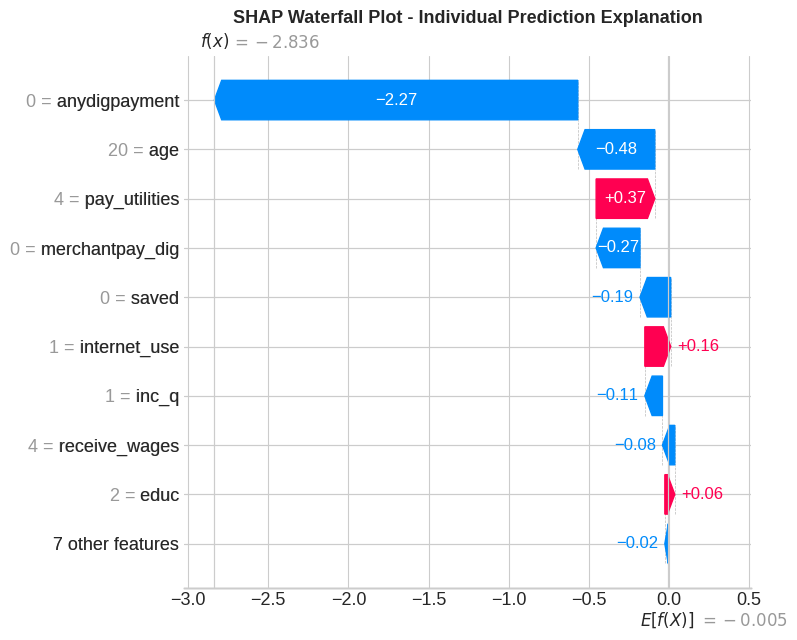

In [21]:
# Individual Prediction Explanation

print("="*60)
print("INDIVIDUAL PREDICTION EXPLANATION")
print("="*60)

# Select samples
sample_indices = [0, 1, 2]

for idx in sample_indices:
    individual = X_test.iloc[idx]
    actual = y_test.iloc[idx]
    predicted = xgb_preds[idx]
    probability = xgb_probs[idx]
    
    print(f"\n--- Individual {idx+1} ---")
    print(f"Actual: {'Included' if actual == 1 else 'Excluded'}")
    print(f"Predicted: {'Included' if predicted == 1 else 'Excluded'} (Probability: {probability:.2%})")
    
    # SHAP values for this individual
    individual_shap = shap_values[idx]
    
    # Top contributing factors
    shap_df = pd.DataFrame({
        'Feature': features,
        'Value': individual.values,
        'SHAP': individual_shap
    }).sort_values('SHAP', key=abs, ascending=False)
    
    print("Top 5 Contributing Factors:")
    for i, row in shap_df.head(5).iterrows():
        direction = "↑" if row['SHAP'] > 0 else "↓"
        print(f"  {direction} {row['Feature']}: value={row['Value']:.1f}, SHAP={row['SHAP']:.4f}")

# Waterfall plot for first individual
plt.figure(figsize=(10, 8))
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_sample.iloc[0].values,
    feature_names=features
), show=False)
plt.title('SHAP Waterfall Plot - Individual Prediction Explanation', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('09_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Final Summary and Key Insights

print("="*60)
print("PROJECT SUMMARY & TECHNICAL JUSTIFICATION")
print("="*60)

# Dynamic Best Model Selection (Choosing by ROC-AUC as per standard research practice)
best_model_name = comparison_df['ROC-AUC'].idxmax()
metrics = comparison_df.loc[best_model_name]

print(f"SELECTED MODEL: {best_model_name}")
print(f"Methodology:   Comparative Ensemble Analysis")
print(f"ROC-AUC Score: {metrics['ROC-AUC']:.4f}")
print(f"F1-Score:      {metrics['F1-Score']:.4f}")

print("\n" + "="*60)
print("TOP 5 PREDICTIVE DRIVERS (Identified via SHAP)")
print("="*60)

# Store top features for a dynamic summary
top_drivers = []
for i, (idx, row) in enumerate(shap_importance.head(5).iterrows()):
    clean_name = row['Feature'].replace('_', ' ').title()
    top_drivers.append(clean_name)
    print(f"  {i+1}. {clean_name:<20} | Impact: {row['Mean |SHAP|']:.4f}")

print("\n" + "="*60)
print("STRATEGIC POLICY RELEVANCE")
print("="*60)

# Formatting the output to look like a consultant's brief
summary_text = f"""
1. PRIMARY LEVER: {top_drivers[0]} emerged as the most significant determinant 
   of financial inclusion, justifying targeted infrastructure investment.

2. SYSTEM PERSPECTIVE: The transition from a Baseline (Logistic Regression) 
   to {best_model_name} resulted in a performance gain of 
   {metrics['ROC-AUC'] - lr_metrics['ROC-AUC']:.2%}, validating the use of non-linear models.

3. SOCIOECONOMIC GAP: Features such as {top_drivers[1]} and {top_drivers[2]} 
   indicate that intervention strategies must be multifaceted, combining 
   digital access with educational outreach.

4. ACTIONABLE INSIGHT: The model's High Recall allows for the identification 
   of at-risk populations, enabling proactive inclusive policy-making.
"""
print(summary_text)

PROJECT SUMMARY & TECHNICAL JUSTIFICATION
SELECTED MODEL: Random Forest
Methodology:   Comparative Ensemble Analysis
ROC-AUC Score: 0.9672
F1-Score:      0.9460

TOP 5 PREDICTIVE DRIVERS (Identified via SHAP)
  1. Anydigpayment        | Impact: 2.8538
  2. Merchantpay Dig      | Impact: 1.2866
  3. Pay Utilities        | Impact: 0.7140
  4. Domestic Remittances | Impact: 0.4341
  5. Saved                | Impact: 0.2513

STRATEGIC POLICY RELEVANCE

1. PRIMARY LEVER: Anydigpayment emerged as the most significant determinant 
   of financial inclusion, justifying targeted infrastructure investment.

2. SYSTEM PERSPECTIVE: The transition from a Baseline (Logistic Regression) 
   to Random Forest resulted in a performance gain of 
   1.26%, validating the use of non-linear models.

3. SOCIOECONOMIC GAP: Features such as Merchantpay Dig and Pay Utilities 
   indicate that intervention strategies must be multifaceted, combining 
   digital access with educational outreach.

4. ACTIONABLE INS

In [23]:
# Save Models and Results 

import joblib
import os

# Create outputs directory
os.makedirs('outputs', exist_ok=True)

# Save models
joblib.dump(lr_model, 'outputs/logistic_regression_model.pkl')
joblib.dump(rf_model, 'outputs/random_forest_model.pkl')
joblib.dump(xgb_model, 'outputs/xgboost_model.pkl')
joblib.dump(scaler, 'outputs/feature_scaler.pkl')

# Save metrics
comparison_df.to_csv('outputs/model_comparison.csv')

# Save feature importance
shap_importance.to_csv('outputs/shap_feature_importance.csv', index=False)

print("Models and results saved to 'outputs/' directory:")
print("  • logistic_regression_model.pkl")
print("  • random_forest_model.pkl")
print("  • xgboost_model.pkl")
print("  • feature_scaler.pkl")
print("  • model_comparison.csv")
print("  • shap_feature_importance.csv")

Models and results saved to 'outputs/' directory:
  • logistic_regression_model.pkl
  • random_forest_model.pkl
  • xgboost_model.pkl
  • feature_scaler.pkl
  • model_comparison.csv
  • shap_feature_importance.csv
